In [2]:

# Import Libraries

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:

# Dataset Loading

apple_path = "../datasets/fresh_rotten/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple"

print(os.listdir(apple_path))

['Fresh', 'Rotten']


In [5]:
fresh_path = apple_path + "/Fresh"
rotten_path = apple_path + "/Rotten"

fresh_images = os.listdir(fresh_path)
rotten_images = os.listdir(rotten_path)

print("Fresh apples:", len(fresh_images))
print("Rotten apples:", len(rotten_images))

Fresh apples: 124
Rotten apples: 55


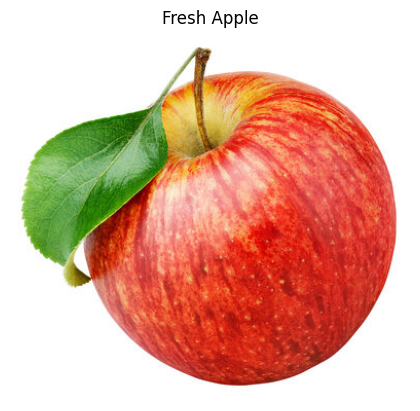

In [6]:

# Data Visualization

fresh_img = cv2.imread(fresh_path + "/" + fresh_images[0])

fresh_img = cv2.cvtColor(fresh_img, cv2.COLOR_BGR2RGB)

plt.imshow(fresh_img)
plt.title("Fresh Apple")
plt.axis("off")

plt.show()

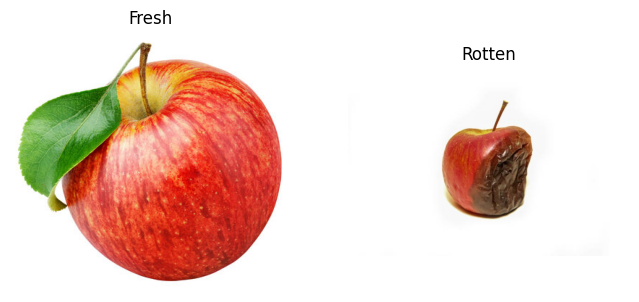

In [7]:
rotten_img = cv2.imread(rotten_path + "/" + rotten_images[0])

rotten_img = cv2.cvtColor(rotten_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(fresh_img)
plt.title("Fresh")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(rotten_img)
plt.title("Rotten")
plt.axis("off")

plt.show()

In [8]:

# Data Augmentation

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

print("Augmentation ready")

Augmentation ready


In [9]:
train_generator = train_datagen.flow_from_directory(
    apple_path,
    target_size=(128,128),
    batch_size=16,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    apple_path,
    target_size=(128,128),
    batch_size=16,
    class_mode='binary',
    subset='validation'
)

Found 137 images belonging to 2 classes.
Found 33 images belonging to 2 classes.


In [7]:

#CNN model creation

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.summary()


C:\Users\Bhavna Anand\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:

# Training

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

C:\Users\Bhavna Anand\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 384ms/step - accuracy: 0.5912 - loss: 2.3583 - val_accuracy: 0.6970 - val_loss: 0.4928
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 310ms/step - accuracy: 0.7007 - loss: 0.4817 - val_accuracy: 0.7879 - val_loss: 0.4080
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 290ms/step - accuracy: 0.9270 - loss: 0.2953 - val_accuracy: 0.9091 - val_loss: 0.2608
Epoch 4/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 288ms/step - accuracy: 0.9489 - loss: 0.1521 - val_accuracy: 0.8788 - val_loss: 0.2030
Epoch 5/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 266ms/step - accuracy: 0.9708 - loss: 0.1113 - val_accuracy: 0.9091 - val_loss: 0.1993


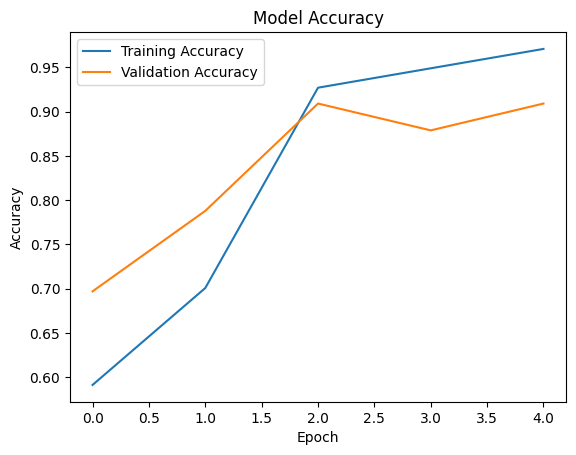

In [12]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [4]:
import pandas as pd

quality_df = pd.read_csv(
    "../datasets/apple_quality/apple_quality.csv"
)

quality_df.head()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good


In [14]:
quality_df["Quality"].value_counts()

Quality
good    2004
bad     1996
Name: count, dtype: int64

In [15]:
quality_df.describe()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,1999.500000,-0.503015,-0.989547,-0.470479,0.985478,0.512118,0.498277
std,1154.844867,1.928059,1.602507,1.943441,1.402757,1.930286,1.874427
min,0.000000,-7.151703,-7.149848,-6.894485,-6.055058,-5.961897,-5.864599
25%,999.750000,-1.816765,-2.011770,-1.738425,0.062764,-0.801286,-0.771677
50%,1999.500000,-0.513703,-0.984736,-0.504758,0.998249,0.534219,0.503445
75%,2999.250000,0.805526,0.030976,0.801922,1.894234,1.835976,1.766212
max,3999.000000,6.406367,5.790714,6.374916,7.619852,7.364403,7.237837


In [16]:

# Quality Grading Logic

def assign_grade(row):

    if row["Quality"] == "bad":
        return "Grade C"

    score = 0

    if row["Size"] > 0.8:
        score += 1

    if row["Weight"] > 0:
        score += 1

    if row["Sweetness"] > 0.8:
        score += 1

    if row["Juiciness"] > 1.8:
        score += 1


    if score >= 3:
        return "Grade A"

    else:
        return "Grade B"


quality_df["Grade"] = quality_df.apply(assign_grade, axis=1)

quality_df["Grade"].value_counts()

Grade
Grade C    1996
Grade B    1901
Grade A     104
Name: count, dtype: int64

In [17]:

# Final Grading System

def final_grade(freshness, quality_grade):

    if freshness == "Rotten":
        return "Grade C"

    if freshness == "Fresh" and quality_grade == "Grade A":
        return "Grade A"

    if freshness == "Fresh" and quality_grade == "Grade B":
        return "Grade B"

    return "Grade C"


print(final_grade("Fresh", "Grade A"))
print(final_grade("Fresh", "Grade B"))
print(final_grade("Rotten", "Grade A"))

Grade A
Grade B
Grade C


In [8]:
# Save trained CNN model

model.save(
    "../models/apple_freshness_model.h5"
)

print("Model saved successfully!")

# Verify save location
model_path = "../models"

print("Files in models folder:")
print(os.listdir(model_path))

Model saved successfully!
Files in models folder:
['apple_freshness_model.h5']
